# PPO from scratch — CartPole

We build PPO with explicit, inspectable components:
- **PolicyNetwork** (actor): maps state → action probabilities
- **ValueNetwork** (critic): maps state → V(s)
- **GAE**: generalised advantage estimation
- **PPO objective**: clipped surrogate loss

No Stable Baselines, no abstractions. Every step is visible.

## 0. Installs

In [1]:
# !pip install gymnasium torch matplotlib

## 1. Imports

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from gymnasium.envs.classic_control.cartpole import CartPoleEnv
from typing import cast
import matplotlib.pyplot as plt
from collections import deque

torch.manual_seed(42)
np.random.seed(42)

# Larger default fonts for all figures
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. The Policy Network (Actor)

Maps a state s → probability distribution over actions.

For CartPole: state is 4D (cart position, cart velocity, pole angle, pole angular velocity).
Actions are discrete: push left (0) or push right (1).

The output layer uses **softmax** so we get a valid probability distribution.
We then sample from this distribution — this is what makes it a *stochastic* policy.

In [3]:
class PolicyNetwork(nn.Module):
    """
    The ACTOR: π_θ(a | s)
    
    Input:  state s  (shape: [batch, state_dim])
    Output: action probabilities  (shape: [batch, n_actions])
    """
    def __init__(self, state_dim: int, n_actions: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_actions),
        )
    
    def forward(self, state: torch.Tensor) -> Categorical:
        """Returns a Categorical distribution over actions."""
        logits = self.net(state)          # raw unnormalised scores
        return Categorical(logits=logits) # wraps in softmax internally
    
    def get_action(self, state: torch.Tensor):
        """Sample an action and return (action, log_prob)."""
        dist = self.forward(state)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob
    
    def evaluate(self, state: torch.Tensor, action: torch.Tensor):
        """
        Used during the PPO update:
        given (state, action) from OLD policy,
        return log_prob and entropy under CURRENT policy.
        """
        dist = self.forward(state)
        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()         # used to encourage exploration
        return log_prob, entropy


# Quick sanity check
env_test = gym.make("CartPole-v1")
assert env_test is not None

obs_space = env_test.observation_space
act_space = env_test.action_space
assert obs_space is not None
obs_shape = getattr(obs_space, "shape", None)
assert obs_shape is not None and len(obs_shape) > 0

assert act_space is not None
n_actions = getattr(act_space, "n", None)
assert n_actions is not None

STATE_DIM = int(obs_shape[0])  # 4
N_ACTIONS = int(n_actions)  # 2
env_test.close()

policy = PolicyNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
dummy_state = torch.zeros(1, STATE_DIM).to(DEVICE)

action, lp = policy.get_action(dummy_state)
print(f"\nPolicy architecture:\n{policy}")

print(f"State dim: {STATE_DIM}, Action dim: {N_ACTIONS}")
print(f"Sample action: {action.item()}, log_prob: {lp.item():.3f}")



Policy architecture:
PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
State dim: 4, Action dim: 2
Sample action: 0, log_prob: -0.605


## 3. The Value Network (Critic)

Maps a state s → scalar V(s): the expected future discounted return.

The critic is NOT used to select actions — it's only used to compute **advantages**:

```
A(s, a) = Q(s, a) - V(s)
         ≈ (reward + γ·V(s') - V(s))   ← TD residual
```

A positive advantage means the action was better than average → increase its probability.
A negative advantage means it was worse than average → decrease its probability.

In [4]:
class ValueNetwork(nn.Module):
    """
    The CRITIC: V_φ(s)
    
    Input:  state s  (shape: [batch, state_dim])
    Output: scalar value estimate  (shape: [batch, 1])
    """
    def __init__(self, state_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),     # single scalar output
        )
    
    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return self.net(state).squeeze(-1)  # shape: [batch]


value_net = ValueNetwork(STATE_DIM).to(DEVICE)
v = value_net(dummy_state)
print(f"V(s) for zero state: {v.item():.4f}")
print(f"\nValue network architecture:\n{value_net}")

V(s) for zero state: 0.0349

Value network architecture:
ValueNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 4. Rollout Buffer

PPO is **on-policy**: we collect a batch of experience under the current policy,
run several gradient update epochs on it, then throw it away and repeat.

The buffer stores:
- `states` — what the agent observed
- `actions` — what it did
- `log_probs_old` — log π_old(a|s) — needed for the importance ratio r_t
- `rewards` / `dones` — to compute returns
- `values` — V(s) at each step — for GAE

In [5]:
class RolloutBuffer:
    """Stores one batch of on-policy experience."""
    
    def __init__(self):
        self.states      = []
        self.actions     = []
        self.log_probs   = []  # log π_old(a|s) at collection time
        self.rewards     = []
        self.dones       = []
        self.values      = []  # V(s) at collection time
    
    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)
    
    def clear(self):
        self.__init__()
    
    def to_tensors(self):
        return (
            torch.FloatTensor(np.array(self.states)).to(DEVICE),
            torch.LongTensor(self.actions).to(DEVICE),
            torch.FloatTensor(self.log_probs).to(DEVICE),
            self.rewards,
            self.dones,
            torch.FloatTensor(self.values).to(DEVICE),
        )

print("RolloutBuffer defined.")

RolloutBuffer defined.


## 5. Generalised Advantage Estimation (GAE)

GAE computes advantages as an exponentially-weighted sum of TD residuals:

```
δ_t    = r_t + γ·V(s_{t+1}) - V(s_t)      ← TD residual (1-step advantage)
A_t^GAE = δ_t + (γλ)·δ_{t+1} + (γλ)²·δ_{t+2} + ...
```

**λ=0**: pure TD(0) — low variance, high bias (only looks 1 step ahead)
**λ=1**: Monte Carlo returns — unbiased but high variance
**λ=0.95**: the standard PPO setting — balances both

We compute this backwards through the trajectory (more numerically stable).

In [6]:
def compute_gae(
    rewards: list,
    dones: list,
    values: torch.Tensor,
    last_value: float,
    gamma: float = 0.99,
    lam: float = 0.95,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Returns:
      advantages  (shape: [T])  — used in the policy loss
      returns     (shape: [T])  — used as targets for the value network
    """
    T = len(rewards)
    advantages = torch.zeros(T).to(DEVICE)
    
    gae = 0.0
    for t in reversed(range(T)):
        # Bootstrap from last_value at the end of the rollout
        next_value = last_value if t == T - 1 else values[t + 1].item()
        next_non_terminal = 1.0 - float(dones[t])
        
        # TD residual: how much better/worse was this step than V predicted?
        delta = rewards[t] + gamma * next_value * next_non_terminal - values[t].item()
        
        # Accumulate discounted sum of deltas (backwards)
        gae = delta + gamma * lam * next_non_terminal * gae
        advantages[t] = gae
    
    # Returns = advantages + values  (targets for the critic)
    returns = advantages + values
    
    # Normalise advantages: zero mean, unit std
    # This stabilises training significantly
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
    return advantages, returns

print("GAE function defined.")

GAE function defined.


## 6. PPO Update Step

This is the heart of PPO. Given a collected batch, we run K epochs of gradient updates.

**Policy loss (clipped surrogate)**:
```
r_t(θ) = π_θ(a|s) / π_θ_old(a|s)     ← importance ratio
         = exp(log_prob_new - log_prob_old)   ← numerically stable form

L_CLIP = E[ min( r_t · A_t,  clip(r_t, 1-ε, 1+ε) · A_t ) ]
```

**Value loss**: MSE between V_φ(s) and the GAE returns.

**Entropy bonus**: encourages exploration by penalising confident distributions.

In [7]:
def ppo_update(
    policy:        PolicyNetwork,
    value_net:     ValueNetwork,
    optimizer:     optim.Optimizer,
    states:        torch.Tensor,
    actions:       torch.Tensor,
    log_probs_old: torch.Tensor,
    advantages:    torch.Tensor,
    returns:       torch.Tensor,
    # ---- PPO hyperparameters ----
    clip_eps:      float = 0.2,   # ε in the clip objective
    n_epochs:      int   = 10,    # how many gradient steps per batch
    batch_size:    int   = 64,
    vf_coef:       float = 0.5,   # weight of value loss
    ent_coef:      float = 0.01,  # weight of entropy bonus
) -> dict:
    """Run K epochs of PPO updates on the collected rollout."""
    
    T = states.shape[0]
    metrics = {"policy_loss": [], "value_loss": [], "entropy": [], "clip_frac": []}
    
    for _ in range(n_epochs):
        # Shuffle indices for mini-batching
        indices = torch.randperm(T)
        
        for start in range(0, T, batch_size):
            mb_idx = indices[start : start + batch_size]
            
            mb_states    = states[mb_idx]
            mb_actions   = actions[mb_idx]
            mb_log_old   = log_probs_old[mb_idx]
            mb_adv       = advantages[mb_idx]
            mb_returns   = returns[mb_idx]
            
            # --- Policy loss ---
            log_probs_new, entropy = policy.evaluate(mb_states, mb_actions)
            
            # Importance ratio: how much has the policy changed?
            ratio = torch.exp(log_probs_new - mb_log_old)  # r_t(θ)
            
            # Unclipped and clipped objectives
            surr1 = ratio * mb_adv
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * mb_adv
            
            policy_loss = -torch.min(surr1, surr2).mean()  # negative because we ascend
            
            # --- Value loss ---
            values_pred = value_net(mb_states)
            value_loss  = nn.functional.mse_loss(values_pred, mb_returns)
            
            # --- Entropy bonus (negative because we want to maximise entropy) ---
            entropy_loss = -entropy.mean()
            
            # --- Combined loss ---
            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss
            
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(  # prevent exploding gradients
                list(policy.parameters()) + list(value_net.parameters()), 
                max_norm=0.5
            )
            optimizer.step()
            
            # Track what fraction of ratios got clipped (diagnostic)
            clip_frac = ((ratio - 1.0).abs() > clip_eps).float().mean().item()
            
            metrics["policy_loss"].append(policy_loss.item())
            metrics["value_loss"].append(value_loss.item())
            metrics["entropy"].append(-entropy_loss.item())
            metrics["clip_frac"].append(clip_frac)
    
    return {k: np.mean(v) for k, v in metrics.items()}

print("PPO update function defined.")

PPO update function defined.


## 7. Training Loop

The PPO training cycle:

```
repeat:
  1. Collect N steps in the environment using CURRENT policy
  2. Compute GAE advantages over the rollout
  3. Run K epochs of mini-batch gradient updates
  4. Clear the buffer, go back to 1
```

Note: we share a single Adam optimizer across both networks.

In [8]:
class ExternalForcing(gym.Wrapper):
    """Wind load on the pole: mean wind plus von Kármán turbulent gusts.

    Wind speed:  u(t) = U + u'(t), where the gust u'(t) is a sum of Fourier
    modes with amplitudes from the von Kármán spectrum and random phases,
    drawn fresh at every reset.
    Drag:        F(t) = 1/2 rho C_d A |u| u, with A = pole diameter x pole length.
    The drag is spread uniformly along the pole, so its resultant acts at
    mid-pole (height l above the pivot). The agent never observes the wind.
    """

    def __init__(
        self,
        env,
        mean_wind=2.5,              # U, m/s
        turbulence_intensity=0.3,   # sigma_u / U
        length_scale=5.0,           # L, turbulence integral length scale, m
        air_density=1.2,            # rho, kg/m^3
        drag_coefficient=1.2,       # C_d, circular cylinder
        pole_diameter=0.02,         # D, m
        n_modes=400,                # Fourier modes in the gust synthesis
    ):
        super().__init__(env)
        base = self._cartpole_env()
        self.mean_wind = float(mean_wind)
        self.air_density = float(air_density)
        self.drag_coefficient = float(drag_coefficient)
        self.frontal_area = float(pole_diameter) * 2.0 * float(base.length)  # D x full pole length
        sigma_u = float(turbulence_intensity) * self.mean_wind
        self.integral_time = float(length_scale) / self.mean_wind  # T_L = L / U, s

        # Von Kármán one-sided spectrum of u': S(f) = sigma^2 4 T_L / (1 + 70.8 (f T_L)^2)^(5/6).
        # Modes span 0.02 Hz up to 20 Hz (below the 25 Hz Nyquist rate of the 0.02 s step).
        self.frequencies = np.geomspace(0.02, 20.0, int(n_modes))
        spectrum = sigma_u**2 * 4.0 * self.integral_time / (
            1.0 + 70.8 * (self.frequencies * self.integral_time) ** 2
        ) ** (5.0 / 6.0)
        self.mode_amplitudes = np.sqrt(2.0 * spectrum * np.gradient(self.frequencies))
        self._phases = np.zeros(int(n_modes))
        self._step_count = 0
        self.wind_speed: float = self.mean_wind  # u in the last step, m/s
        self.wind_force: float = 0.0             # drag resultant in the last step, N

    def _cartpole_env(self) -> CartPoleEnv:
        return cast(CartPoleEnv, self.env.unwrapped)

    def drag(self, u):
        return 0.5 * self.air_density * self.drag_coefficient * self.frontal_area * np.abs(u) * u

    def gust(self, t):
        """Turbulent fluctuation u'(t) in m/s for the current episode's phases."""
        return float(np.sum(self.mode_amplitudes * np.cos(2.0 * np.pi * self.frequencies * t + self._phases)))

    def _apply_horizontal_impulse(self, force, height):
        """Apply a horizontal force at `height` above the pivot, through the true dynamics."""
        base_env = self._cartpole_env()
        if base_env.state is None:
            return

        x, x_dot, theta, theta_dot = map(float, base_env.state)
        mass_cart = float(base_env.masscart)
        mass_pole = float(base_env.masspole)
        half_length = float(base_env.length)  # Gymnasium's `length` is HALF the pole
        dt = float(base_env.tau)
        cos_theta = float(np.cos(theta))

        # A force applied for one environment step produces this impulse.
        impulse = float(force) * dt

        # Mass matrix of Gymnasium's cart + uniform-rod pole: centre of mass at
        # half_length, inertia about the pivot (4/3) m l^2.
        matrix = np.array(
            [
                [mass_cart + mass_pole, mass_pole * half_length * cos_theta],
                [mass_pole * half_length * cos_theta, (4.0 / 3.0) * mass_pole * half_length**2],
            ],
            dtype=np.float64,
        )
        # Generalized impulse for a horizontal force at x + h sin θ:
        # linear impulse J and angular impulse J * h * cos(theta).
        generalized_impulse = np.array(
            [impulse, impulse * float(height) * cos_theta],
            dtype=np.float64,
        )
        delta_x_dot, delta_theta_dot = np.linalg.solve(matrix, generalized_impulse)

        base_env.state = np.array(
            (
                x,
                x_dot + delta_x_dot,
                theta,
                theta_dot + delta_theta_dot,
            ),
            dtype=np.float64,
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._phases = np.random.uniform(0.0, 2.0 * np.pi, self.frequencies.size)  # new gusts
        self._step_count = 0
        self.wind_speed = self.mean_wind + self.gust(0.0)
        self.wind_force = 0.0
        return obs, info

    def step(self, action):
        base_env = self._cartpole_env()
        t = self._step_count * float(base_env.tau)
        self._step_count += 1
        self.wind_speed = self.mean_wind + self.gust(t)
        self.wind_force = float(self.drag(self.wind_speed))
        self._apply_horizontal_impulse(self.wind_force, height=float(base_env.length))  # mid-pole
        return self.env.step(action)


class PerceptionLatency(gym.Wrapper):
    """The agent perceives the cart-pole state `latency` seconds late.

    Each observation holds the last `n_frames` perceived (delayed) states plus
    the actions taken since the newest one (+1 right, -1 left). From these the
    policy can predict the current state forward, like latency compensation in
    an autonomous-vehicle stack.
    """

    def __init__(self, env, latency=0.04, n_frames=2):
        super().__init__(env)
        dt = float(cast(CartPoleEnv, env.unwrapped).tau)
        self.latency_steps = int(round(float(latency) / dt))
        if not np.isclose(self.latency_steps * dt, latency):
            raise ValueError(f"latency must be a multiple of the time step ({dt} s)")
        self.n_frames = max(1, int(n_frames))
        self._state_history: deque = deque(maxlen=self.latency_steps + self.n_frames)
        self._action_history: deque = deque(maxlen=self.latency_steps)
        obs_dim = 4 * self.n_frames + self.latency_steps
        self.observation_space = gym.spaces.Box(
            -np.inf, np.inf, shape=(obs_dim,), dtype=np.float32
        )
        self.perceived_state = np.zeros(4, dtype=np.float32)  # newest state the agent sees

    def _observation(self):
        # History is always full: the newest perceived frame is latency_steps
        # steps behind the true state.
        frames = list(self._state_history)[: self.n_frames]
        self.perceived_state = frames[-1].copy()
        actions = np.asarray(self._action_history, dtype=np.float32)
        return np.concatenate(frames + [actions]).astype(np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # Pad the history with the initial state and "no action".
        obs = np.asarray(obs, dtype=np.float32)
        self._state_history.clear()
        for _ in range(self.latency_steps + self.n_frames):
            self._state_history.append(obs.copy())
        self._action_history.clear()
        for _ in range(self.latency_steps):
            self._action_history.append(0.0)
        return self._observation(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._state_history.append(np.asarray(obs, dtype=np.float32).copy())
        self._action_history.append(1.0 if int(action) == 1 else -1.0)
        return self._observation(), reward, terminated, truncated, info


# ── Hyperparameters ──────────────────────────────────────────────────────────
ROLLOUT_STEPS  = 2048    # steps to collect per update
N_EPOCHS       = 10      # PPO epochs per rollout
BATCH_SIZE     = 64      # mini-batch size within each epoch
GAMMA          = 0.99    # discount factor
GAE_LAMBDA     = 0.95    # GAE λ
CLIP_EPS       = 0.2     # PPO clip range ε
LR             = 3e-4    # learning rate
VF_COEF        = 0.5     # value loss coefficient
ENT_COEF       = 0.01    # entropy bonus coefficient
TOTAL_STEPS    = 300_000 # enough for the policy to learn under wind forcing
PERCEPTION_LATENCY = 0.04  # s, how late the agent perceives the state (2 time steps)
N_FRAMES       = 2       # perceived frames in each observation

# ── Environment & Buffer ─────────────────────────────────────────────────────
env    = PerceptionLatency(
    ExternalForcing(gym.make("CartPole-v1")),  # wind: 2.5 m/s mean, 30% turbulence (defaults)
    latency=PERCEPTION_LATENCY,
    n_frames=N_FRAMES,
)
LATENCY_STEPS = env.latency_steps
buffer = RolloutBuffer()

# Observation = N_FRAMES perceived frames + LATENCY_STEPS recent actions
STATE_DIM = int(env.observation_space.shape[0])

# ── Networks & Optimizer ─────────────────────────────────────────────────────
policy    = PolicyNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
value_net = ValueNetwork(STATE_DIM).to(DEVICE)

# Single optimizer across both networks (standard PPO practice)
optimizer = optim.Adam(
    list(policy.parameters()) + list(value_net.parameters()),
    lr=LR
)

# ── Logging ──────────────────────────────────────────────────────────────────
episode_rewards   = []
ep_reward_history = []    # one entry per episode
update_metrics    = []
rolling_avg       = deque(maxlen=50)

state, _ = env.reset()
ep_reward: float = 0.0
total_steps: int = 0
update_count: int = 0

print(f"Training PPO on CartPole-v1 with wind forcing and perception latency")
print(
    f"Rollout steps: {ROLLOUT_STEPS} | Epochs/update: {N_EPOCHS} | Clip ε: {CLIP_EPS} | "
    f"Perception latency: {PERCEPTION_LATENCY * 1000:.0f} ms | Frames: {N_FRAMES} | Obs dim: {STATE_DIM}"
)
print("-" * 60)

while total_steps < TOTAL_STEPS:
    # ── Phase 1: Collect rollout ──────────────────────────────────────────
    for _ in range(ROLLOUT_STEPS):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            action, log_prob = policy.get_action(state_t)
            value = value_net(state_t)

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        # Hitting the 500-step time limit is not a failure: bootstrap from
        # V(s') so GAE doesn't treat truncation like the pole falling over.
        buffer_reward = float(reward)
        if truncated and not terminated:
            with torch.no_grad():
                next_state_t = torch.FloatTensor(next_state).unsqueeze(0).to(DEVICE)
                buffer_reward += GAMMA * value_net(next_state_t).item()

        buffer.store(
            state=state,
            action=action.item(),
            log_prob=log_prob.item(),
            reward=buffer_reward,
            done=done,
            value=value.item(),
        )

        ep_reward = float(ep_reward) + float(reward)
        total_steps = int(total_steps) + 1
        state = next_state

        if done:
            ep_reward_history.append(ep_reward)
            rolling_avg.append(ep_reward)
            ep_reward = 0.0
            state, _ = env.reset()

    # ── Phase 2: Compute advantages ───────────────────────────────────────
    states_t, actions_t, log_probs_t, rewards, dones, values_t = buffer.to_tensors()

    with torch.no_grad():
        last_state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        last_value = value_net(last_state_t).item()

    advantages, returns = compute_gae(
        rewards, dones, values_t, last_value, GAMMA, GAE_LAMBDA
    )

    # ── Phase 3: PPO update ───────────────────────────────────────────────
    metrics = ppo_update(
        policy, value_net, optimizer,
        states_t, actions_t, log_probs_t,
        advantages, returns,
        clip_eps=CLIP_EPS, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
        vf_coef=VF_COEF, ent_coef=ENT_COEF,
    )
    update_metrics.append(metrics)
    update_count += 1

    # ── Phase 4: Clear buffer ─────────────────────────────────────────────
    buffer.clear()

    # Logging every 5 updates
    if update_count % 5 == 0:
        avg_reward = np.mean(rolling_avg) if rolling_avg else 0
        print(
            f"Step {total_steps:>7,} | "
            f"Avg reward (50ep): {avg_reward:>6.1f} | "
            f"π loss: {metrics['policy_loss']:>6.4f} | "
            f"V loss: {metrics['value_loss']:>6.4f} | "
            f"Entropy: {metrics['entropy']:.3f} | "
            f"Clip frac: {metrics['clip_frac']:.3f}"
        )

    # Stop once we hit the step budget
    if total_steps >= TOTAL_STEPS:
        break

print("\nTraining complete.")

# close environment after training
env.close()

Training PPO on CartPole-v1 with wind forcing and perception latency
Rollout steps: 2048 | Epochs/update: 10 | Clip ε: 0.2 | Perception latency: 40 ms | Frames: 2 | Obs dim: 10
------------------------------------------------------------


Step  10,240 | Avg reward (50ep):   63.2 | π loss: -0.0082 | V loss: 69.4888 | Entropy: 0.610 | Clip frac: 0.029


Step  20,480 | Avg reward (50ep):  135.2 | π loss: -0.0037 | V loss: 48.1541 | Entropy: 0.559 | Clip frac: 0.026


Step  30,720 | Avg reward (50ep):  200.2 | π loss: -0.0037 | V loss: 32.2734 | Entropy: 0.532 | Clip frac: 0.040


Step  40,960 | Avg reward (50ep):  298.8 | π loss: -0.0035 | V loss: 62.0739 | Entropy: 0.499 | Clip frac: 0.062


...

Step 266,240 | Avg reward (50ep):  357.0 | π loss: -0.0054 | V loss: 35.2191 | Entropy: 0.434 | Clip frac: 0.060


Step 276,480 | Avg reward (50ep):  375.9 | π loss: -0.0051 | V loss: 25.6400 | Entropy: 0.401 | Clip frac: 0.045


Step 286,720 | Avg reward (50ep):  396.0 | π loss: -0.0000 | V loss: 18.8021 | Entropy: 0.413 | Clip frac: 0.094


Step 296,960 | Avg reward (50ep):  401.2 | π loss: -0.0059 | V loss: 63.5080 | Entropy: 0.442 | Clip frac: 0.054



Training complete.


### Wind forcing

The wind used in training over one 10 s episode: wind speed $u(t) = U + u'(t)$ with von Kármán gusts, and the resulting drag on the pole. The gusts are random (seeded here for reproducibility) and drawn fresh every episode in training. Each value is held constant for one 0.02 s step.

wind speed: mean 2.43 m/s, std 0.72 m/s | drag: mean 0.093 N, min 0.010 N, max 0.224 N


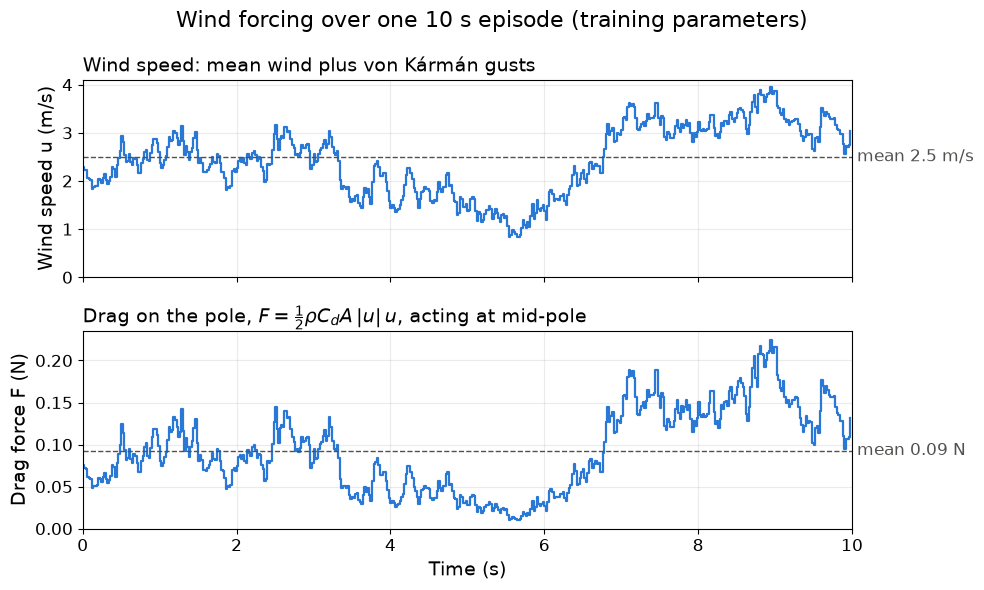

In [9]:
# Wind forcing over one episode, with the training parameters.
# The wind does not depend on the cart-pole state, so it can be sampled directly.
forcing_demo = ExternalForcing(gym.make("CartPole-v1"))
np.random.seed(0)  # reproducible gust phases
forcing_demo.reset(seed=0)
dt = float(forcing_demo.unwrapped.tau)
n_steps = 500  # one full episode, 10 s
t_start = np.arange(n_steps) * dt  # each value holds over [t_start, t_start + dt)
wind = np.array([forcing_demo.mean_wind + forcing_demo.gust(t) for t in t_start])
force = forcing_demo.drag(wind)
forcing_demo.close()
print(f"wind speed: mean {wind.mean():.2f} m/s, std {wind.std():.2f} m/s | "
      f"drag: mean {force.mean():.3f} N, min {force.min():.3f} N, max {force.max():.3f} N")

SERIES_COLOR = "#2a78d6"
fig, (ax_u, ax_f) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_u.step(t_start, wind, where="post", color=SERIES_COLOR, lw=1.6)
ax_u.axhline(forcing_demo.mean_wind, color="#52514e", lw=1, ls="--")
ax_u.text(n_steps * dt, forcing_demo.mean_wind, f" mean {forcing_demo.mean_wind} m/s",
          va="center", ha="left", fontsize=12, color="#52514e")
ax_u.set_ylim(bottom=0)
ax_u.set_ylabel("Wind speed u (m/s)")
ax_u.set_title("Wind speed: mean wind plus von Kármán gusts", loc="left")

ax_f.step(t_start, force, where="post", color=SERIES_COLOR, lw=1.6)
ax_f.axhline(force.mean(), color="#52514e", lw=1, ls="--")
ax_f.text(n_steps * dt, force.mean(), f" mean {force.mean():.2f} N",
          va="center", ha="left", fontsize=12, color="#52514e")
ax_f.set_ylim(bottom=0)
ax_f.set_ylabel("Drag force F (N)")
ax_f.set_title(r"Drag on the pole, $F = \frac{1}{2}\rho C_d A\,|u|\,u$, acting at mid-pole",
               loc="left")
ax_f.set_xlabel("Time (s)")
ax_f.set_xlim(0, n_steps * dt)
for ax in (ax_u, ax_f):
    ax.grid(True, alpha=0.25)
fig.suptitle("Wind forcing over one 10 s episode (training parameters)")
fig.tight_layout()
fig.savefig("resources/external_forcing.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Training Diagnostics

What to look for:
- **Episode reward** should climb toward ~500 (CartPole max)
- **Policy loss** noisy but generally near zero
- **Value loss** should decrease as the critic learns V(s)
- **Entropy** should gradually decrease as the policy becomes more confident
- **Clip fraction** should stay below ~0.2 — if it's high, the policy is changing too fast

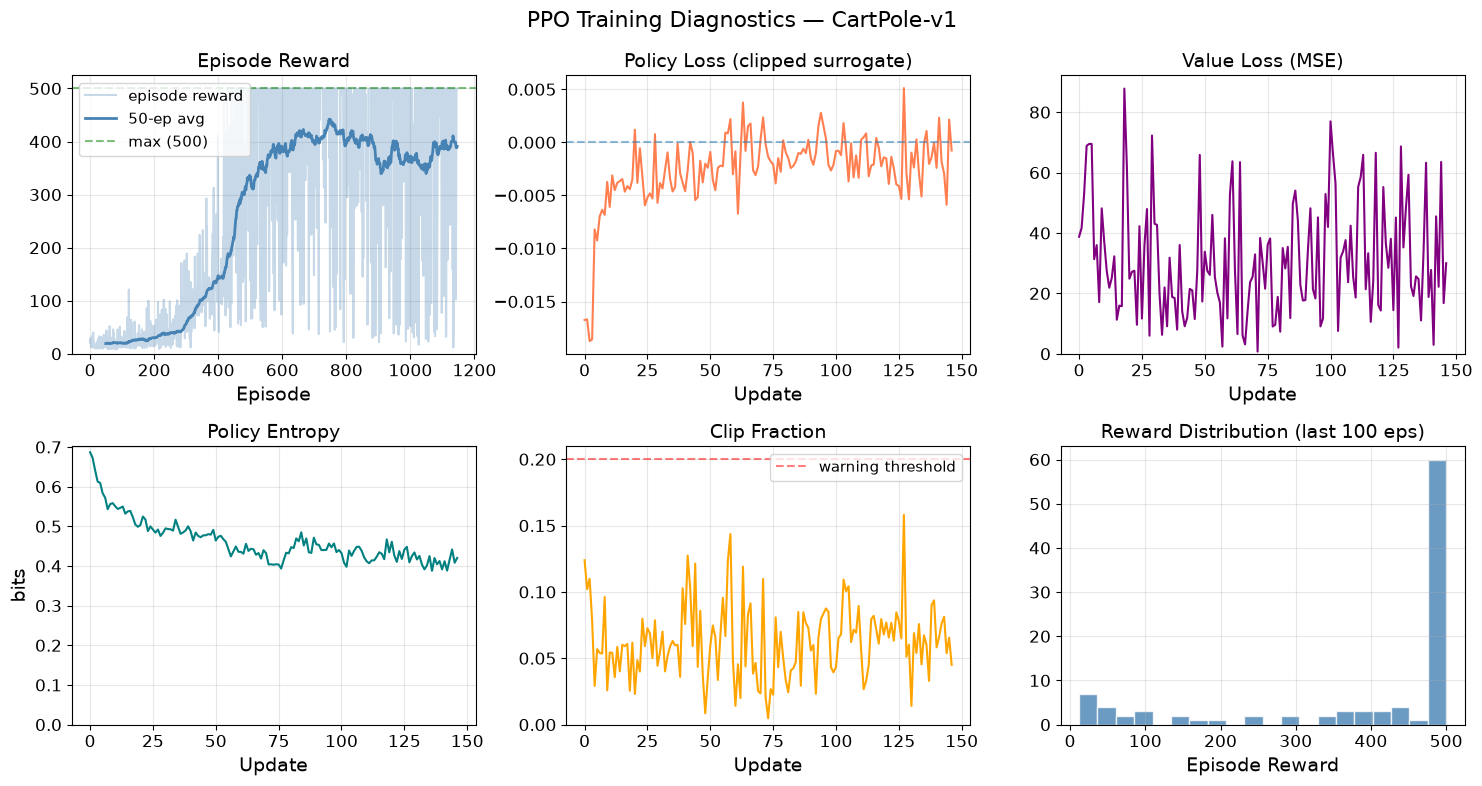

Final 50-episode avg reward: 391.0


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("PPO Training Diagnostics — CartPole-v1")

# Episode rewards
ax = axes[0, 0]
ax.plot(ep_reward_history, alpha=0.3, color="steelblue", label="episode reward")
window = 50
if len(ep_reward_history) >= window:
    smoothed = np.convolve(ep_reward_history, np.ones(window)/window, mode="valid")
    ax.plot(range(window-1, len(ep_reward_history)), smoothed, color="steelblue", linewidth=2, label=f"{window}-ep avg")
ax.axhline(500, linestyle="--", color="green", alpha=0.5, label="max (500)")
ax.set_title("Episode Reward")
ax.set_ylim(bottom=0)
ax.set_xlabel("Episode")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Extract per-update metrics
policy_losses = [m["policy_loss"] for m in update_metrics]
value_losses  = [m["value_loss"]  for m in update_metrics]
entropies     = [m["entropy"]     for m in update_metrics]
clip_fracs    = [m["clip_frac"]   for m in update_metrics]

# Policy loss
ax = axes[0, 1]
ax.plot(policy_losses, color="coral")
ax.set_title("Policy Loss (clipped surrogate)")
ax.set_xlabel("Update")
ax.axhline(0, linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

# Value loss
ax = axes[0, 2]
ax.plot(value_losses, color="purple")
ax.set_title("Value Loss (MSE)")
ax.set_ylim(bottom=0)
ax.set_xlabel("Update")
ax.grid(True, alpha=0.3)

# Entropy
ax = axes[1, 0]
ax.plot(entropies, color="teal")
ax.set_title("Policy Entropy")
ax.set_ylim(bottom=0)
ax.set_xlabel("Update")
ax.set_ylabel("bits")
ax.grid(True, alpha=0.3)

# Clip fraction
ax = axes[1, 1]
ax.plot(clip_fracs, color="orange")
ax.axhline(0.2, linestyle="--", color="red", alpha=0.5, label="warning threshold")
ax.set_title("Clip Fraction")
ax.set_ylim(bottom=0)
ax.set_xlabel("Update")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Reward distribution (final 100 episodes)
ax = axes[1, 2]
final_rewards = ep_reward_history[-100:] if len(ep_reward_history) >= 100 else ep_reward_history
ax.hist(final_rewards, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_title(f"Reward Distribution (last {len(final_rewards)} eps)")
ax.set_xlabel("Episode Reward")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resources/ppo_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Final 50-episode avg reward: {np.mean(ep_reward_history[-50:]):.1f}")

## 9. Inspect the learned policy

Examine what the policy has learned: action probabilities as a function of pole angle.

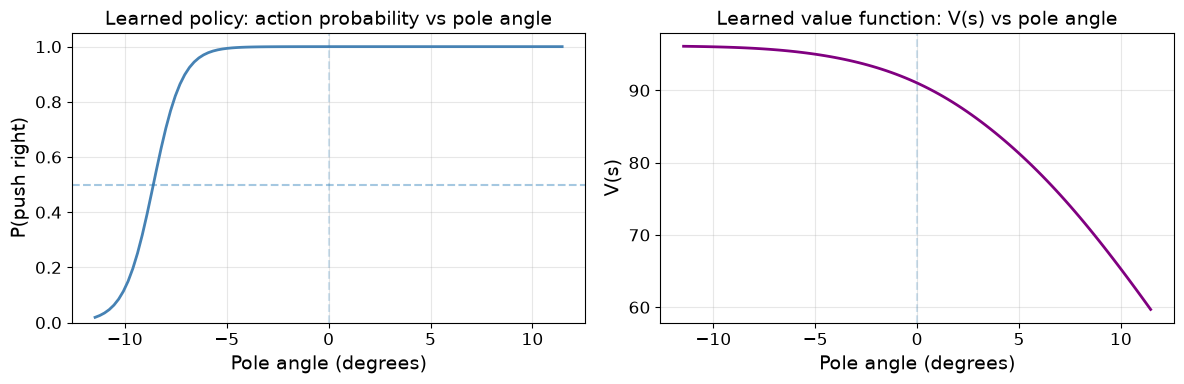

In [11]:
policy.eval()
value_net.eval()

# Sweep pole angle from -0.2 to 0.2 radians (index 2 in each frame)
# Keep all other state dimensions at zero
angles = np.linspace(-0.2, 0.2, 100)
probs_right = []
values_at_angle = []


def probe_observation(angle: float) -> list:
    """Steady state at `angle`: same frame in every frame slot, no recent actions."""
    # frame: [cart_pos, cart_vel, pole_angle, pole_angular_vel]
    frame = [0.0, 0.0, float(angle), 0.0]
    return frame * N_FRAMES + [0.0] * LATENCY_STEPS


with torch.no_grad():
    for angle in angles:
        state_vec = torch.FloatTensor([probe_observation(angle)]).to(DEVICE)
        dist  = policy(state_vec)
        probs = dist.probs[0].cpu().numpy()
        value = value_net(state_vec).item()
        probs_right.append(probs[1])   # prob of pushing right
        values_at_angle.append(value)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(np.degrees(angles), probs_right, color="steelblue", linewidth=2)
ax1.axhline(0.5, linestyle="--", alpha=0.4)
ax1.axvline(0, linestyle="--", alpha=0.2)
ax1.set_xlabel("Pole angle (degrees)")
ax1.set_ylabel("P(push right)")
ax1.set_ylim(bottom=0)
ax1.set_title("Learned policy: action probability vs pole angle")
ax1.grid(True, alpha=0.3)

# Expected: when pole tilts right (+angle), agent pushes right
# When pole tilts left (-angle), agent pushes left

ax2.plot(np.degrees(angles), values_at_angle, color="purple", linewidth=2)
ax2.axvline(0, linestyle="--", alpha=0.2)
ax2.set_xlabel("Pole angle (degrees)")
ax2.set_ylabel("V(s)")
ax2.set_title("Learned value function: V(s) vs pole angle")
ax2.grid(True, alpha=0.3)

# Expected: V(s) peaks near angle=0 (upright = high expected return)
# and falls off as the pole tilts further

plt.tight_layout()
plt.savefig("resources/policy_inspection.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Experiments to try

Break things deliberately to build intuition:

```python
# 1. Disable clipping — watch training destabilise
CLIP_EPS = 1.0   # effectively no clip

# 2. Single epoch — sample inefficient, slower convergence
N_EPOCHS = 1

# 3. No entropy bonus — policy collapses to deterministic too early
ENT_COEF = 0.0

# 4. λ=0 in GAE — pure TD(0), high bias, smooth but slow
GAE_LAMBDA = 0.0

# 5. λ=1 in GAE — Monte Carlo, unbiased but high variance, noisy
GAE_LAMBDA = 1.0

# 6. No advantage normalisation — comment out the normalisation in compute_gae()
#    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

# 7. Shared network — combine actor and critic into one network with two heads
#    (more parameter efficient, used in many production implementations)
```

## 11. Render a trained episode as an animation

This cell rolls out a trained policy in CartPole and saves a GIF so you can watch the agent behave after training.

It uses Gymnasium's `rgb_array` render mode, which is the easiest way to capture frames for an animation.

In [12]:
# Render a trained rollout and save a GIF
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageDraw

policy.eval()
value_net.eval()

# Same wind as in training (ExternalForcing defaults).
forcing_render = ExternalForcing(gym.make("CartPole-v1", render_mode="rgb_array"))
env_render = PerceptionLatency(forcing_render, latency=PERCEPTION_LATENCY, n_frames=N_FRAMES)
# Evaluate the deterministic policy on 20 seeded episodes (training forcing),
# then record the longest one as the GIF. The seed fixes both the initial
# condition and the random impulses, so the rendered episode replays exactly.
def episode_length(seed: int) -> int:
    np.random.seed(seed)
    eval_env = PerceptionLatency(
        ExternalForcing(gym.make("CartPole-v1")), latency=PERCEPTION_LATENCY, n_frames=N_FRAMES
    )
    o, _ = eval_env.reset(seed=seed)
    n = 0
    while True:
        with torch.no_grad():
            a = policy(torch.FloatTensor(o).unsqueeze(0).to(DEVICE)).probs.argmax(dim=-1).item()
        o, _, term, trunc, _ = eval_env.step(a)
        n += 1
        if term or trunc:
            eval_env.close()
            return n

eval_lengths = {seed: episode_length(seed) for seed in range(20)}
print("Evaluation episode lengths (steps):", list(eval_lengths.values()))
print(f"Median: {np.median(list(eval_lengths.values())):.0f} | "
      f"reached 500: {sum(v == 500 for v in eval_lengths.values())}/20")
GIF_SEED = max(eval_lengths, key=eval_lengths.get)
print(f"Recording seed {GIF_SEED} ({eval_lengths[GIF_SEED]} steps)")
np.random.seed(GIF_SEED)
obs, _ = env_render.reset(seed=GIF_SEED)
state = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
frames = []

# Match Gymnasium's renderer geometry so the arrow sits on the drawn pole tip.
render_base = cast(CartPoleEnv, env_render.unwrapped)
px_per_m = render_base.screen_width / (2 * render_base.x_threshold)  # 125 px/m
pole_len_px = px_per_m * 2 * render_base.length                      # full pole
# Renderer puts the pivot at y = carty + axleoffset = 100 + 30/4, then flips vertically.
pivot_y = render_base.screen_height - (100 + 30 / 4)
WIND_PX_PER_N = 350.0  # arrow length per newton of total drag (0.2 N -> 70 px)
N_LOAD_ARROWS = 7
POLE_HALF_WIDTH_PX = 5.0  # Gymnasium draws the pole 10 px wide
WIND_COLOR = (42, 120, 214, 255)  # blue

for _ in range(500):
    with torch.no_grad():
        dist = policy(state)
        action = dist.probs.argmax(dim=-1)

    obs, reward, terminated, truncated, _ = env_render.step(action.item())
    frame = env_render.render()
    if frame is None:
        continue

    # Draw the wind as a uniform load along the pole: evenly spaced horizontal
    # arrows whose heads touch the upwind face of the pole, with their tails
    # joined by a continuous line (the load envelope). Arrow length is
    # proportional to the total drag force; arrows point downwind.
    force = float(forcing_render.wind_force)
    cart_pos, pole_angle = map(float, np.asarray(render_base.state)[[0, 2]])
    pivot_x = render_base.screen_width / 2 + cart_pos * px_per_m
    pil_img = Image.fromarray(np.asarray(frame)).convert("RGBA")
    draw = ImageDraw.Draw(pil_img)

    arrow_len = force * WIND_PX_PER_N  # signed: + means wind blowing to the right
    if abs(arrow_len) >= 2.0:
        direction = np.sign(arrow_len)
        head_len = min(9.0, abs(arrow_len))
        # Horizontal distance from the pole's centerline to its face (pole drawn 10 px wide)
        face_offset = POLE_HALF_WIDTH_PX / max(np.cos(pole_angle), 1e-3)
        tails = []
        for frac in np.linspace(0.08, 0.92, N_LOAD_ARROWS):  # points along the pole
            cx = pivot_x + np.sin(pole_angle) * pole_len_px * frac
            cy = pivot_y - np.cos(pole_angle) * pole_len_px * frac
            head_x = cx - direction * face_offset  # upwind face
            tail_x = head_x - arrow_len
            base_x = head_x - direction * head_len
            draw.line((tail_x, cy, base_x, cy), fill=WIND_COLOR, width=2)
            draw.polygon([(head_x, cy), (base_x, cy - 4), (base_x, cy + 4)], fill=WIND_COLOR)
            tails.append((tail_x, cy))
        draw.line(tails, fill=WIND_COLOR, width=2)  # load envelope

    draw.text((12, 12), f"wind {forcing_render.wind_speed:4.1f} m/s   drag {force:.2f} N",
              fill=(0, 0, 0, 255))

    frames.append(np.array(pil_img.convert("RGB")))

    # Stop at the episode boundary so the GIF never jumps to a new reset state.
    if terminated or truncated:
        break
    state = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)

env_render.close()

print(f"Captured {len(frames)} frames for one continuous rollout")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(frames[0])
ax.axis("off")

def update(frame_idx):
    im.set_data(frames[frame_idx])
    return [im]

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=30,
    blit=True,
)

anim.save("resources/cartpole_trained_rollout.gif", writer=PillowWriter(fps=30))
print("Saved GIF as resources/cartpole_trained_rollout.gif")
plt.close(fig)

# Save a force-vs-angle diagnostic locally in the project folder.
angles = []
forces = []
lagged_angles = []

# Re-run a short policy trajectory with the same physical disturbance model.
plot_forcing = ExternalForcing(gym.make("CartPole-v1"))  # training wind
plot_env = PerceptionLatency(plot_forcing, latency=PERCEPTION_LATENCY, n_frames=N_FRAMES)
plot_base = cast(CartPoleEnv, plot_env.unwrapped)
np.random.seed(GIF_SEED)
obs, _ = plot_env.reset(seed=GIF_SEED)
state_plot = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)

for _ in range(300):
    with torch.no_grad():
        dist = policy(state_plot)
        action = dist.probs.argmax(dim=-1)
    obs, reward, terminated, truncated, _ = plot_env.step(action.item())
    # PerceptionLatency already delays observations; record the newest frame the policy saw.
    lagged_angles.append(float(plot_env.perceived_state[2]))
    angles.append(float(np.asarray(plot_base.state)[2]))
    forces.append(float(plot_forcing.wind_force))
    state_plot = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
    if terminated or truncated:
        obs, _ = plot_env.reset()
        state_plot = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)

plot_env.close()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(angles, forces, s=10, alpha=0.7, color="crimson")
ax.set_xlabel("True pole angle, θ (rad)")
ax.set_ylabel("Wind drag on the pole, F (N)")
ax.set_title("Wind drag vs true pole angle")
ax.axhline(0.0, color="black", lw=0.8, alpha=0.5)
ax.axvline(0.0, color="black", lw=0.8, alpha=0.5)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig("resources/forcing_vs_angle.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved wind-vs-angle figure as resources/forcing_vs_angle.png")

# Save the delayed-observation comparison so the latency is visible in a figure.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles, label="true angle", linewidth=1.6, alpha=0.9)
ax.plot(lagged_angles, label=f"perceived angle ({PERCEPTION_LATENCY * 1000:.0f} ms latency)", linewidth=1.6, alpha=0.8)
ax.set_xlabel("time step")
ax.set_ylabel("pole angle (rad)")
ax.set_title("True angle vs perceived angle")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig("resources/angle_delay_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved delayed-observation comparison as resources/angle_delay_comparison.png")

Evaluation episode lengths (steps): [500, 500, 336, 357, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
Median: 500 | reached 500: 18/20
Recording seed 0 (500 steps)


Captured 500 frames for one continuous rollout


Saved GIF as resources/cartpole_trained_rollout.gif
Saved wind-vs-angle figure as resources/forcing_vs_angle.png
Saved delayed-observation comparison as resources/angle_delay_comparison.png
